# 6 Fine-tuning for classification

In [1]:
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"


def download_and_unzip_spam_data(
    url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download "
        "and extraction."
        )
        return
    
    with urllib.request.urlopen(url) as response: # Downloads the file
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    with zipfile.ZipFile(zip_path, "r") as zip_ref: # Unzips the file
        zip_ref.extractall(extracted_path)

    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path) # Adds a .tsv file extension
    print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)


sms_spam_collection/SMSSpamCollection.tsv already exists. Skipping download and extraction.


In [2]:
import pandas as pd
df = pd.read_csv(
    data_file_path, sep="\t", header=None, names=["Label", "Text"]
)
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [3]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


In [4]:
# Creating a balanced dataset

def created_balanced_dataset(df):
    num_spam = df[df["Label"] == "spam"].shape[0] # Counts the instances of "spam"
    ham_subset = df[df["Label"] == "ham"].sample(
        num_spam, random_state=123
    ) # Randomly samples "ham" instances to match the number of "spam" instances
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]]) # Combines ham subset with "spam"
    return balanced_df

balanced_df = created_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


In [5]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

In [6]:
# Splitting the dataset

def random_split(df, train_frac, validation_frac):

    df = df.sample(
        frac=1, random_state=123
    ).reset_index(drop=True) # Shuffles the entire DataFrame
    train_end = int(len(df) * train_frac) # Calculates split indices
    validation_end = train_end + int(len(df) * validation_frac)

    
    # Splits the DataFrame
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1) # Test size is implied to be 0.2 as the remainder.

In [7]:
train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

In [8]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [9]:
# Setting up a Pytorch Dataset class

import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        # Pretokenizes texts
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            
            # Truncates sequences if they are longer than max_length
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

        self.encoded_texts = [
            encoded_text + [pad_token_id] *
            (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

        # Pads sequences to the longest sequence
        self.encoded_texts = [
            encoded_text + [pad_token_id] *
            (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )
    
    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length

In [10]:
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)

In [11]:
print(train_dataset.max_length)

120


In [12]:
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

In [13]:
# Creating PyTorch data loaders

from torch.utils.data import DataLoader

num_workers = 0 # This setting ensures compatibility with most computers.
batch_size = 8
torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

In [14]:
for input_batch, target_batch in train_loader:
    pass
print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions:", target_batch.shape)

Input batch dimensions: torch.Size([8, 120])
Label batch dimensions: torch.Size([8])


In [15]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


### 6.4 Initializing a model with pretrained weights

In [16]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"
BASE_CONFIG = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024,    # Context length
    "drop_rate": 0.0,    # Dropout rate
    "qkv_bias": True    # Query-key-value bias
}
model_configs = {
    'gpt2-small (124M)': {'emb_dim': 768, 'n_layers': 12, 'n_heads': 12},
    'gpt2-medium (355M)': {'emb_dim': 1024, 'n_layers': 24, 'n_heads': 16},
    'gpt2-large (774M)': {'emb_dim': 1280, 'n_layers': 36, 'n_heads': 20},
    'gpt2-xl (1558M)': {'emb_dim': 1600, 'n_layers': 48, 'n_heads': 25}
    }
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [17]:
import sys
sys.path.append("../ch04")
sys.path.append("../ch05")

from gpt_download import download_and_load_gpt2
from ch05 import GPTModel, load_weights_into_gpt

model_size = CHOOSE_MODEL.split(" ")[-1].strip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size, models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [18]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

In [19]:
from ch04_gpt_model import generate_text_simple
from ch05 import text_to_token_ids, token_ids_to_text

text_1 = "Every effort moves you"
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


In [20]:
# Before we start fine-tuning the model as a spam classifier, let's see whether the model already classifies spam messages by prompting it with instructions

text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


In [21]:
# The model is struggling to follow instructions. Which if expected, as it has only undergone pretraining and lacks instruction fine-tuning.

In [22]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [23]:
for param in model.parameters():
    param.requires_grad = False

In [24]:
torch.manual_seed(123)
num_classes = 2
model.out_head = torch.nn.Linear(
    in_features=BASE_CONFIG["emb_dim"],
    out_features=num_classes
)

In [25]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True

In [26]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape)   # shape:(batch_size, num_tokens)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


In [27]:
with torch.no_grad():
    outputs = model(inputs)
print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape)

Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Outputs dimensions: torch.Size([1, 4, 2])


In [28]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


In [29]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


In [30]:
probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas)
print("Class label:", label.item())

Class label: 1


In [31]:
logits = outputs[:, -1, :]
label = torch.argmax(logits)
print("Class label:", label.item())

Class label: 1


In [32]:
# calculating the classification accuracy

def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)
            

            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]   # Logits of last output token
            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples += predicted_labels.shape[0]
            correct_predictions += (
                (predicted_labels == target_batch).sum().item()
            )
        else:
            break
    return correct_predictions / num_examples

In [33]:
# Let's use the function to determine the classification accuracies across various datasets estimated from 10 batches for efficiency

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

torch.manual_seed(123)
train_accuracy = calc_accuracy_loader(
    train_loader, model, device, num_batches=10
)
val_accuracy = calc_accuracy_loader(
    val_loader, model, device, num_batches=10
)
test_accuracy = calc_accuracy_loader(
    test_loader, model, device, num_batches=10
)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


In [34]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)[:, -1, :]   # Logits of last output token
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

In [35]:
# Calculating the classification loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [36]:
with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)
print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.453
Validation loss: 2.583
Test loss: 2.322


Next, we will implement a training function to fine-tune the model, which means adjusting the model to minimize the training set loss. Minimizing the training set loss will help increase the classification accuracy, which is our overall goal.

In [37]:
# Fine-tuning the model to classify spam

def train_classifier_simple(
        model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []     # Initialize lists to track losses and examples seen
    examples_seen, global_step = 0, -1

    for epoch in range(num_epochs):     # main training loop
        model.train()   # Sets model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()   # Resets loss gradients from the previous batch iteration
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()     # Calculates loss gradients
            optimizer.step()    # Updates model weights using loss gradients
            examples_seen += input_batch.shape[0]   # New: tracks examples instead of tokens
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, "
                    f"Val loss {val_loss:.3f}")
            
        # Calculates accuracy after each epoch
        train_accuracy = calc_accuracy_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_accuracy = calc_accuracy_loader(
            val_loader, model, device, num_batches=eval_iter
        )

        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

In [38]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss

In [39]:
import time
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5

train_losses, val_losses, train_accs, val_accs, examples_seen = \
train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50,
    eval_iter=5
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.153, Val loss 2.392
Ep 1 (Step 000050): Train loss 0.617, Val loss 0.637
Ep 1 (Step 000100): Train loss 0.523, Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.561, Val loss 0.489
Ep 2 (Step 000200): Train loss 0.419, Val loss 0.397
Ep 2 (Step 000250): Train loss 0.409, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300): Train loss 0.333, Val loss 0.320
Ep 3 (Step 000350): Train loss 0.340, Val loss 0.306
Training accuracy: 90.00% | Validation accuracy: 90.00%
Ep 4 (Step 000400): Train loss 0.136, Val loss 0.200
Ep 4 (Step 000450): Train loss 0.153, Val loss 0.132
Ep 4 (Step 000500): Train loss 0.222, Val loss 0.137
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 0.207, Val loss 0.143
Ep 5 (Step 000600): Train loss 0.083, Val loss 0.074
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 5.42 mi

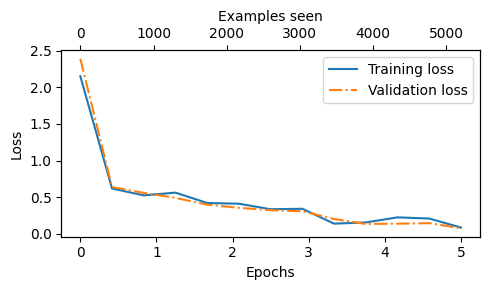

In [49]:
# Plotting the classification loss

import matplotlib.pyplot as plt

def plot_values(
        epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5,3))

    # Plots training and validation loss against epochs
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(
        epochs_seen, val_values, linestyle="-.",
        label=f"Validation {label}"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Creates a second x-axis for examples seen
    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)  # Invisible plots for aligning ticks
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # Adjusts layout to make room
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

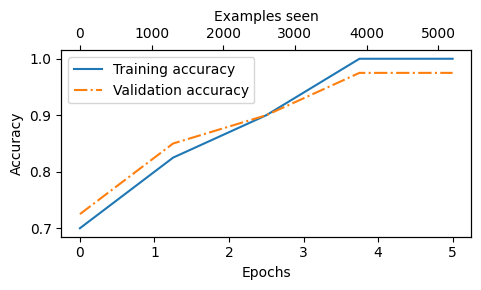

In [52]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(
    epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy"
)

In [53]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 97.21%
Validation accuracy: 97.32%
Test accuracy: 95.67%


In [54]:
# Using the model to classify new texts

def classify_review(
        text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    input_ids = tokenizer.encode(text)  # Prepares inputs to the model
    supported_context_length = model.pos_emb.weight.shape[1]

    # Truncates sequences if they are too long
    input_ids = input_ids[:min(
        max_length, supported_context_length
    )]

    input_ids += [pad_token_id] * (max_length - len(input_ids))     # Pads sequences to the longest sequence

    input_tensor = torch.tensor(
        input_ids, device=device
    ).unsqueeze(0)  # Adds batch dimension

    # Models inference without gradient tracking
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]  # Logits of the last output token
    predicted_label = torch.argmax(logits, dim=-1).item()

    return "spam" if predicted_label == 1 else "not spam"   # Returns the classified result

In [55]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


In [57]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


In [58]:
torch.save(model.state_dict(), "review_classifier.pth")

In [61]:
model_state_dict = torch.load("review_classifier.pth", map_location=device)
model.load_state_dict(model_state_dict)

<All keys matched successfully>

### Exercise 6.1 Increasing the context length

In [62]:
max_length_1024 = model.pos_emb.weight.shape[0]   # 1024, the model's ceiling

train_dataset_1024 = SpamDataset("train.csv", max_length=max_length_1024, tokenizer=tokenizer)
val_dataset_1024   = SpamDataset("validation.csv", max_length=max_length_1024, tokenizer=tokenizer)
test_dataset_1024  = SpamDataset("test.csv", max_length=max_length_1024, tokenizer=tokenizer)

In [67]:
# New dataloaders

from torch.utils.data import DataLoader

torch.manual_seed(123)
batch_size = 8

train_loader_1024 = DataLoader(train_dataset_1024, batch_size=batch_size, shuffle=True,  drop_last=True,  num_workers=0)
val_loader_1024   = DataLoader(val_dataset_1024,   batch_size=batch_size, shuffle=False, drop_last=False, num_workers=0)
test_loader_1024  = DataLoader(test_dataset_1024,  batch_size=batch_size, shuffle=False, drop_last=False, num_workers=0)

In [68]:
# Reset the model to a clean starting point

torch.manual_seed(123)
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)

for param in model.parameters():          # freeze everything
    param.requires_grad = False

torch.manual_seed(123)
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=2)  # fresh 2-class head

for param in model.trf_blocks[-1].parameters():   # unfreeze last block + final norm
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True

model.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [70]:
# Train, with a timer 

import time
start = time.time()

torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader_1024, val_loader_1024, optimizer, device,
    num_epochs=5, eval_freq=50, eval_iter=5
)

print(f"Training time: {(time.time() - start) / 60:.2f} min")

Ep 1 (Step 000000): Train loss 3.840, Val loss 4.255
Ep 1 (Step 000050): Train loss 0.679, Val loss 0.688
Ep 1 (Step 000100): Train loss 0.520, Val loss 0.575
Training accuracy: 75.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.559, Val loss 0.474
Ep 2 (Step 000200): Train loss 0.499, Val loss 0.378
Ep 2 (Step 000250): Train loss 0.477, Val loss 0.385
Training accuracy: 77.50% | Validation accuracy: 80.00%
Ep 3 (Step 000300): Train loss 0.356, Val loss 0.400
Ep 3 (Step 000350): Train loss 0.378, Val loss 0.381
Training accuracy: 85.00% | Validation accuracy: 82.50%
Ep 4 (Step 000400): Train loss 0.298, Val loss 0.358
Ep 4 (Step 000450): Train loss 0.398, Val loss 0.368
Ep 4 (Step 000500): Train loss 0.454, Val loss 0.388
Training accuracy: 87.50% | Validation accuracy: 85.00%
Ep 5 (Step 000550): Train loss 0.360, Val loss 0.383
Ep 5 (Step 000600): Train loss 0.437, Val loss 0.373
Training accuracy: 85.00% | Validation accuracy: 85.00%
Training time: 69.39 min


In [74]:
test_accuracy_full = calc_accuracy_loader(test_loader_1024, model, device)
print(f"Test accuracy (max_length=1024): {test_accuracy_full*100:.2f}%")

Test accuracy (max_length=1024): 80.00%


### Exercise 6.2 Fine-tuning the whole model

In [75]:
torch.manual_seed(123)
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)

num_classes = 2
model.out_head = torch.nn.Linear(BASE_CONFIG["emb_dim"], num_classes)
model.to(device)
# no freeze loop anywhere — all 124M params trainable. That's what makes it 6.2.

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [76]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

In [77]:
import time
start = time.time()
torch.manual_seed(123)
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=5, eval_freq=50, eval_iter=5
)
print(f"Training time: {(time.time()-start)/60:.2f} min")

Ep 1 (Step 000000): Train loss 2.034, Val loss 1.831
Ep 1 (Step 000050): Train loss 0.315, Val loss 0.260
Ep 1 (Step 000100): Train loss 0.151, Val loss 0.616
Training accuracy: 97.50% | Validation accuracy: 97.50%
Ep 2 (Step 000150): Train loss 0.173, Val loss 0.024
Ep 2 (Step 000200): Train loss 0.027, Val loss 0.051
Ep 2 (Step 000250): Train loss 0.030, Val loss 0.060
Training accuracy: 100.00% | Validation accuracy: 95.00%
Ep 3 (Step 000300): Train loss 0.051, Val loss 0.180
Ep 3 (Step 000350): Train loss 0.002, Val loss 0.011
Training accuracy: 100.00% | Validation accuracy: 100.00%
Ep 4 (Step 000400): Train loss 0.001, Val loss 0.105
Ep 4 (Step 000450): Train loss 0.006, Val loss 0.046
Ep 4 (Step 000500): Train loss 0.007, Val loss 0.073
Training accuracy: 100.00% | Validation accuracy: 95.00%
Ep 5 (Step 000550): Train loss 0.007, Val loss 0.042
Ep 5 (Step 000600): Train loss 0.000, Val loss 0.075
Training accuracy: 100.00% | Validation accuracy: 92.50%
Training time: 14.80 min


In [78]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy   = calc_accuracy_loader(val_loader, model, device)
test_accuracy  = calc_accuracy_loader(test_loader, model, device)
print(f"Train: {train_accuracy*100:.2f}% | Val: {val_accuracy*100:.2f}% | Test: {test_accuracy*100:.2f}%")

Train: 100.00% | Val: 96.64% | Test: 98.00%


In [79]:
import torch
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    ax2 = ax1.twiny()                      # second x-axis sharing the y-axis
    ax2.plot(examples_seen, train_values, alpha=0)   # invisible, just aligns ticks
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

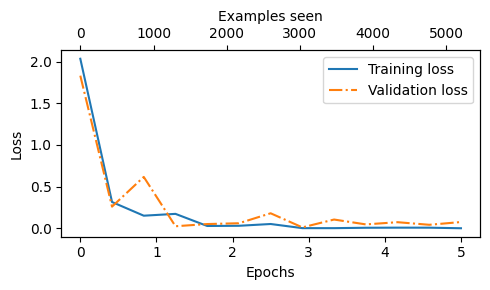

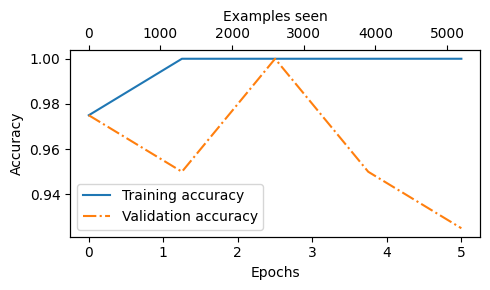

In [80]:
num_epochs = 5   # whatever you trained for

# Loss
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_tensor = torch.linspace(0, examples_seen, len(train_losses))
plot_values(epochs_tensor, examples_tensor, train_losses, val_losses, label="loss")

# Accuracy
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_tensor = torch.linspace(0, examples_seen, len(train_accs))
plot_values(epochs_tensor, examples_tensor, train_accs, val_accs, label="accuracy")

### Exercise 6.3 Fine-tuning the first vs. last token

In [81]:
# Exercise 6.3 — read the classification off a configurable token position
CLS_TOKEN_IDX = 0   # 0 = first token (6.3);  -1 = last token (baseline)

def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, CLS_TOKEN_IDX, :]
    return torch.nn.functional.cross_entropy(logits, target_batch)

def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct, total = 0, 0
    num_batches = len(data_loader) if num_batches is None else min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        input_batch, target_batch = input_batch.to(device), target_batch.to(device)
        with torch.no_grad():
            logits = model(input_batch)[:, CLS_TOKEN_IDX, :]
        preds = torch.argmax(logits, dim=-1)
        total += preds.shape[0]
        correct += (preds == target_batch).sum().item()
    return correct / total

In [82]:
# Reset to the same last-block baseline as the chapter

torch.manual_seed(123)
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)

for param in model.parameters():
    param.requires_grad = False
model.out_head = torch.nn.Linear(BASE_CONFIG["emb_dim"], 2)
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True
model.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [83]:
# Train on the 120-length loaders

import time
start = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=5, eval_freq=50, eval_iter=5
)
print(f"Training time: {(time.time()-start)/60:.2f} min")

Ep 1 (Step 000000): Train loss 0.756, Val loss 0.726
Ep 1 (Step 000050): Train loss 0.674, Val loss 0.711
Ep 1 (Step 000100): Train loss 0.632, Val loss 0.711
Training accuracy: 62.50% | Validation accuracy: 52.50%
Ep 2 (Step 000150): Train loss 0.627, Val loss 0.694
Ep 2 (Step 000200): Train loss 0.594, Val loss 0.675
Ep 2 (Step 000250): Train loss 0.532, Val loss 0.693
Training accuracy: 72.50% | Validation accuracy: 62.50%
Ep 3 (Step 000300): Train loss 0.549, Val loss 0.654
Ep 3 (Step 000350): Train loss 0.483, Val loss 0.673
Training accuracy: 75.00% | Validation accuracy: 55.00%
Ep 4 (Step 000400): Train loss 0.472, Val loss 0.628
Ep 4 (Step 000450): Train loss 0.466, Val loss 0.652
Ep 4 (Step 000500): Train loss 0.441, Val loss 0.628
Training accuracy: 75.00% | Validation accuracy: 65.00%
Ep 5 (Step 000550): Train loss 0.496, Val loss 0.623
Ep 5 (Step 000600): Train loss 0.418, Val loss 0.599
Training accuracy: 80.00% | Validation accuracy: 67.50%
Training time: 5.60 min


In [84]:
# Full evaluation

train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy   = calc_accuracy_loader(val_loader, model, device)
test_accuracy  = calc_accuracy_loader(test_loader, model, device)
print(f"[first token] Train: {train_accuracy*100:.2f}% | Val: {val_accuracy*100:.2f}% | Test: {test_accuracy*100:.2f}%")

[first token] Train: 78.65% | Val: 79.87% | Test: 78.33%
